## Part 01. 선형회귀 직접 구현

w,b를 직접 선언하고 경사하강법으로 학습하기

**Step1. 데이터 생성**

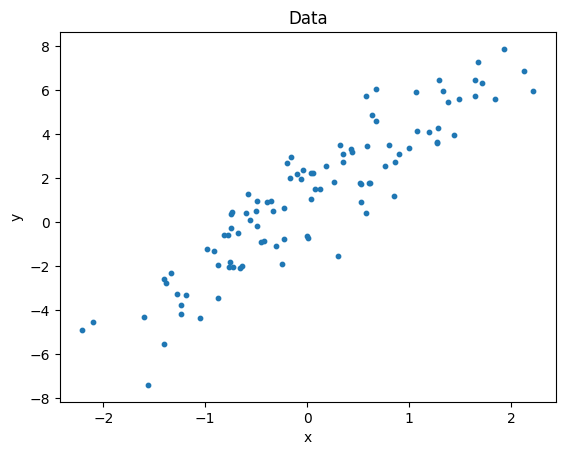

In [1]:
import torch
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 데이터 생성: y = 3x + 1 + noise
torch.manual_seed(42)
x = torch.randn(100, 1)
y = 3 * x + 1 + 1.5 * torch.randn(100, 1)

# 데이터 시각화
plt.scatter(x.numpy(), y.numpy(), s=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data')
plt.show()

**Step2. 파라미터 직접 선언**

In [4]:
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print(f"초기 w: {w.item():.4f}")
print(f"초기 b: {b.item():.4f}")


초기 w: -0.3178
초기 b: -0.4279


**Step3. 학습루프 작성**

데이터를 n등분 -> Batch   
각각의 Batch가 들어간 걸 iteration

In [5]:
learning_rate = 0.1
epochs = 50
losses = []

for epoch in range(epochs):
  # 1) Forward: 예측값 계산
  y_pred = w * x + b

  # 2) Loss: MSE 직접 계산
  loss = ((y_pred - y) ** 2).mean()
  losses.append(loss.item())

  # 3) Backward: 기울기 계산
  loss.backward()

  # 4) 파라미터 업데이트 (경사하강법)
  with torch.no_grad():
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad

  # 5) 기울기 초기화
  w.grad.zero_()
  b.grad.zero_()

  if (epoch + 1) % 5 == 0:
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, "
    f"w: {w.item():.4f}, b: {b.item():.4f}")



Epoch 5, Loss: 3.9517, w: 1.9130, b: 0.6500
Epoch 10, Loss: 1.9855, w: 2.6497, b: 0.9485
Epoch 15, Loss: 1.7803, w: 2.8944, b: 1.0282
Epoch 20, Loss: 1.7585, w: 2.9761, b: 1.0483
Epoch 25, Loss: 1.7561, w: 3.0036, b: 1.0528
Epoch 30, Loss: 1.7558, w: 3.0129, b: 1.0536
Epoch 35, Loss: 1.7558, w: 3.0161, b: 1.0537
Epoch 40, Loss: 1.7558, w: 3.0171, b: 1.0536
Epoch 45, Loss: 1.7558, w: 3.0175, b: 1.0536
Epoch 50, Loss: 1.7558, w: 3.0176, b: 1.0535


**Step4. Loss 그래프 확인**

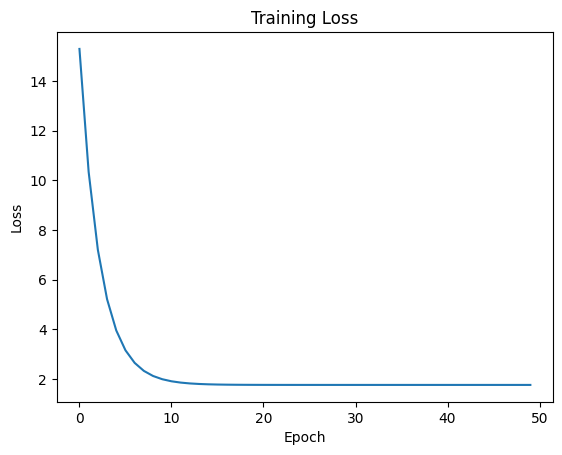

학습된 w: 3.0176 (정답: 3.0)
학습된 b: 1.0535 (정답: 1.0)


In [6]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

print(f"학습된 w: {w.item():.4f} (정답: 3.0)")
print(f"학습된 b: {b.item():.4f} (정답: 1.0)")

Test. 학습률 바꿔보기 (0.1 -> 1.0)


In [7]:
learning_rate = 1.0
epochs = 50
losses = []

for epoch in range(epochs):
  # 1) Forward: 예측값 계산
  y_pred = w * x + b

  # 2) Loss: MSE 직접 계산
  loss = ((y_pred - y) ** 2).mean()
  losses.append(loss.item())

  # 3) Backward: 기울기 계산
  loss.backward()

  # 4) 파라미터 업데이트 (경사하강법)
  with torch.no_grad():
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad

  # 5) 기울기 초기화
  w.grad.zero_()
  b.grad.zero_()

  if (epoch + 1) % 5 == 0:
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, "
    f"w: {w.item():.4f}, b: {b.item():.4f}")



Epoch 5, Loss: 1.7558, w: 3.0178, b: 1.0535
Epoch 10, Loss: 1.7558, w: 3.0177, b: 1.0535
Epoch 15, Loss: 1.7558, w: 3.0178, b: 1.0536
Epoch 20, Loss: 1.7558, w: 3.0176, b: 1.0534
Epoch 25, Loss: 1.7558, w: 3.0179, b: 1.0537
Epoch 30, Loss: 1.7558, w: 3.0175, b: 1.0532
Epoch 35, Loss: 1.7558, w: 3.0180, b: 1.0539
Epoch 40, Loss: 1.7558, w: 3.0172, b: 1.0528
Epoch 45, Loss: 1.7558, w: 3.0185, b: 1.0545
Epoch 50, Loss: 1.7558, w: 3.0165, b: 1.0519


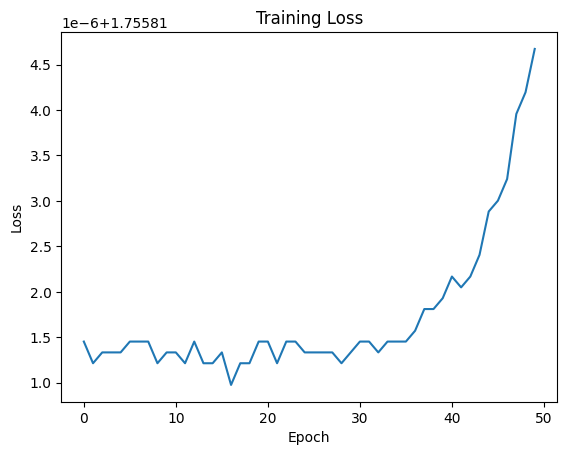

학습된 w: 3.0165 (정답: 3.0)
학습된 b: 1.0519 (정답: 1.0)


In [9]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

print(f"학습된 w: {w.item():.4f} (정답: 3.0)")
print(f"학습된 b: {b.item():.4f} (정답: 1.0)")

Test. 학습률 바꿔보기 (0.1 -> 0.001)

In [12]:
learning_rate = 0.001
epochs = 50
losses = []

for epoch in range(epochs):
  # 1) Forward: 예측값 계산
  y_pred = w * x + b

  # 2) Loss: MSE 직접 계산
  loss = ((y_pred - y) ** 2).mean()
  losses.append(loss.item())

  # 3) Backward: 기울기 계산
  loss.backward()

  # 4) 파라미터 업데이트 (경사하강법)
  with torch.no_grad():
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad

  # 5) 기울기 초기화
  w.grad.zero_()
  b.grad.zero_()

  if (epoch + 1) % 5 == 0:
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, "
    f"w: {w.item():.4f}, b: {b.item():.4f}")



Epoch 5, Loss: 1.7802, w: 2.9254, b: 0.9321
Epoch 10, Loss: 1.7797, w: 2.9264, b: 0.9333
Epoch 15, Loss: 1.7792, w: 2.9273, b: 0.9346
Epoch 20, Loss: 1.7787, w: 2.9283, b: 0.9358
Epoch 25, Loss: 1.7783, w: 2.9292, b: 0.9371
Epoch 30, Loss: 1.7778, w: 2.9301, b: 0.9383
Epoch 35, Loss: 1.7773, w: 2.9311, b: 0.9395
Epoch 40, Loss: 1.7769, w: 2.9320, b: 0.9407
Epoch 45, Loss: 1.7765, w: 2.9328, b: 0.9418
Epoch 50, Loss: 1.7760, w: 2.9337, b: 0.9430


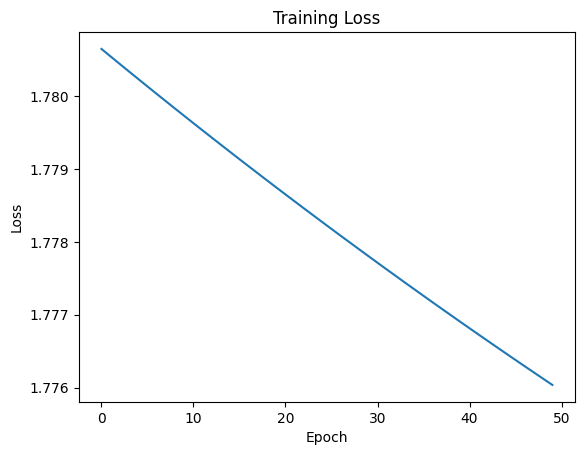

학습된 w: 2.9337 (정답: 3.0)
학습된 b: 0.9430 (정답: 1.0)


In [13]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

print(f"학습된 w: {w.item():.4f} (정답: 3.0)")
print(f"학습된 b: {b.item():.4f} (정답: 1.0)")

## Part 02. 로지스틱 회귀 직접 구현

이진 분류 + Sigmoid + BCE를 코드로 구현하기

**Step1. 이진분류 데이터 생성**

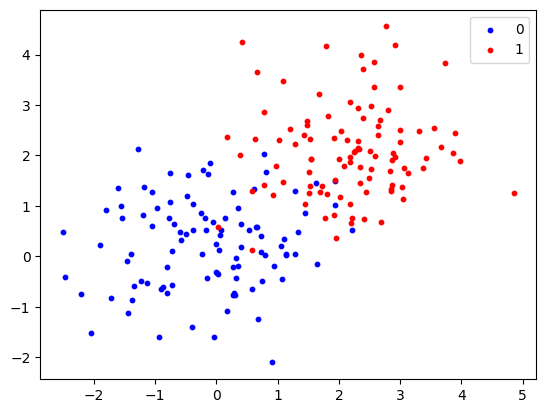

In [15]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)
n = 100

# 클래스 0: 평균 (0, 0)
x0 = torch.randn(n, 2) + torch.tensor([0.0, 0.0])
# 클래스 1: 평균 (2, 2)
x1 = torch.randn(n, 2) + torch.tensor([2.0, 2.0])

X = torch.cat([x0, x1], dim=0) # (200, 2)
Y = torch.cat([torch.zeros(n, 1),
               torch.ones(n, 1)], dim=0) # (200, 1)

plt.scatter(X[:n,0], X[:n,1], c='blue', label='0', s=10)
plt.scatter(X[n:,0], X[n:,1], c='red', label='1', s=10)
plt.legend()
plt.show()

**Step2. Sigmoid 함수와 파라미터 선언**

In [16]:
# Sigmoid 함수 직접 구현
def sigmoid(z):
  return 1 / (1 + torch.exp(-z))

# 파라미터 선언 (입력 2차원 → 출력 1차원)
w = torch.randn(2, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

print(f"w shape: {w.shape}") # torch.Size([2, 1])
print(f"b shape: {b.shape}") # torch.Size([1])


w shape: torch.Size([2, 1])
b shape: torch.Size([1])


**Step3. BCE Loss 직접 구현**

In [17]:
# BCE Loss 직접 구현
def bce_loss(y_pred, y_true):
  eps = 1e-7 # log(0) 방지
  return -(y_true * torch.log(y_pred + eps) +
   (1 - y_true) * torch.log(1 - y_pred + eps)).mean()


**Step4. 학습루프 작성**

In [18]:
learning_rate = 0.1
epochs = 200
losses = []

for epoch in range(epochs):
  # Forward
  z = X @ w + b
  y_pred = sigmoid(z)

  loss = bce_loss(y_pred, Y)
  losses.append(loss.item())

  loss.backward()

  with torch.no_grad():
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad

  w.grad.zero_()
  b.grad.zero_()

  if (epoch + 1) % 50 == 0:
    acc = ((y_pred > 0.5).float() == Y).float().mean()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, "
    f"Acc: {acc.item():.4f}")


Epoch 50, Loss: 0.4018, Acc: 0.8100
Epoch 100, Loss: 0.2853, Acc: 0.9050
Epoch 150, Loss: 0.2445, Acc: 0.9350
Epoch 200, Loss: 0.2239, Acc: 0.9400


**Step5. 결정 경계 시각화**

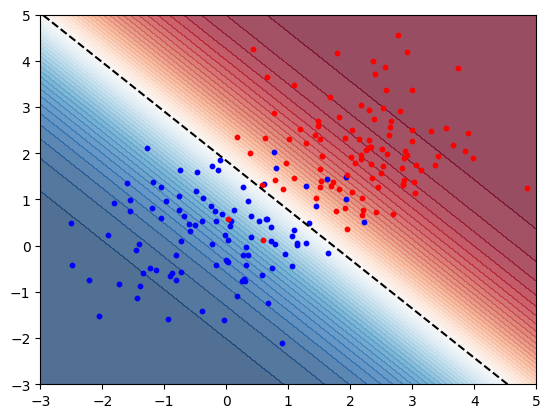

In [19]:
import matplotlib.pyplot as plt

with torch.no_grad():
  x1_range = torch.linspace(-3, 5, 100)
  x2_range = torch.linspace(-3, 5, 100)
  xx1, xx2 = torch.meshgrid(x1_range, x2_range, indexing='ij')
  grid = torch.stack([xx1.flatten(), xx2.flatten()], dim=1)
  probs = sigmoid(grid @ w + b).reshape(100, 100)

  plt.contourf(xx1.numpy(), xx2.numpy(), probs.numpy(), levels=50, cmap='RdBu_r', alpha=0.7)
  plt.contour(xx1.numpy(), xx2.numpy(), probs.numpy(), levels=[0.5], colors='black', linestyles='--')

  plt.scatter(X[:n,0], X[:n,1], c='blue', s=10)
  plt.scatter(X[n:,0], X[n:,1], c='red', s=10)
  plt.show()
